In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import seaborn as sns
#Se carga la tabla de la base de datos
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
#Se transforman datos a un formato util y se limpian datos sin numero o valor(NaN)
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Filtracion de datos en base a la tabla de un país en especifico
df_ch = df[df['job_country']== 'Chile']

In [ ]:
#Se convierten elementos especificos de una columna de una tabla a una fila de datos
df_skills = df.explode('job_skills')
df_skills[['job_title','job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,NaN
1,Data Analyst,r
1,Data Analyst,python
1,Data Analyst,sql
1,Data Analyst,nosql
...,...,...
785739,"Principal Associate, Data Engineer (Remote-Eli...",kafka
785739,"Principal Associate, Data Engineer (Remote-Eli...",kubernetes
785739,"Principal Associate, Data Engineer (Remote-Eli...",docker
785740,AWS System Analyst,aws


In [ ]:
#Contar la cantidad de veces que se menciona una habilidad por ofertas de trabajo
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [8]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles [:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

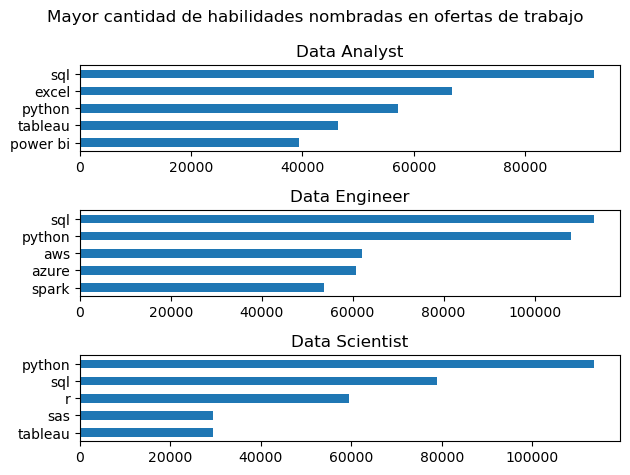

In [12]:
fig, ax = plt.subplots(len(job_titles), 1)

for i,job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']== job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Mayor cantidad de habilidades nombradas en ofertas de trabajo')
fig.tight_layout()
plt.show()

In [14]:
df_job_title_count =df_ch['job_title_short'].value_counts().reset_index(name='jobs_total')

In [19]:
df_skills_percent = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_percent['skill_percent'] =df_skills_percent['skill_count'] / df_skills_percent['jobs_total']
df_skills_percent

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,113711,1824,62.341557
1,sql,Data Engineer,113130,2078,54.441771
2,python,Data Engineer,108022,2078,51.983638
3,sql,Data Analyst,92428,1443,64.052668
4,sql,Data Scientist,78982,1824,43.301535
...,...,...,...,...,...
2251,webex,Senior Data Scientist,1,384,0.002604
2252,codecommit,Business Analyst,1,651,0.001536
2253,xamarin,Machine Learning Engineer,1,233,0.004292
2254,mlr,Machine Learning Engineer,1,233,0.004292


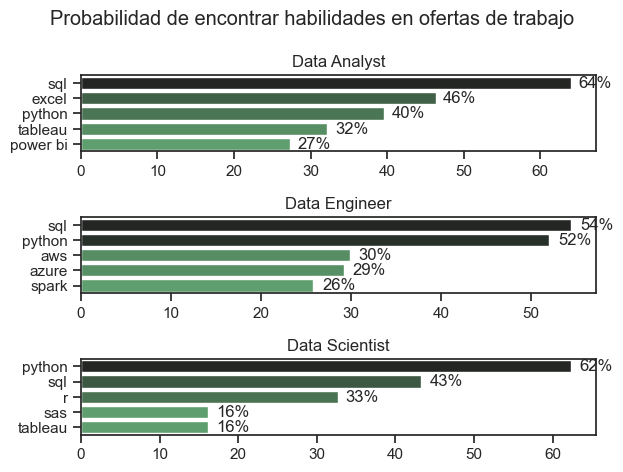

In [32]:
fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style='ticks')
for i,job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent['job_title_short']== job_title].head(5)
    #df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count',palette='dark:g_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Probabilidad de encontrar habilidades en ofertas de trabajo')
fig.tight_layout()
plt.show()